# Module 3 Midweek Project

### 1 - Exploratory Data Analysis (EDA)

##### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Set style for visuals
sns.set(style="whitegrid")

print('All libraries loaded successfully.')

All libraries loaded successfully.


##### Load Data

In [3]:
df = pd.read_excel('Bank_Personal_Loan_Modelling.xlsx', sheet_name='Data')

##### Basic Inspection

In [4]:
# View first few rows
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
# Shape of dataset
df.shape

(5000, 14)

In [6]:
# Column names
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [7]:
# Dataset info (data types, nulls)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


##### Missing Values Check

In [8]:
# Missing values per column
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

##### Descriptive Statistics

In [9]:
# Summary of numerical columns
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937913,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747666,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


##### Unique Values Check

In [10]:
# Unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

ID: 5000
Age: 45
Experience: 47
Income: 162
ZIP Code: 467
Family: 4
CCAvg: 108
Education: 3
Mortgage: 347
Personal Loan: 2
Securities Account: 2
CD Account: 2
Online: 2
CreditCard: 2


##### Duplicate Check

In [11]:
# Duplicate rows
print(df.duplicated().sum())

0


### 2 - Data Cleaning and Data Preparation

##### Data Cleaning

In [12]:
# Drop irrelevant columns (no predictive value)
# ID is just an identifier, ZIP Code is categorical with too many unique values
df = df.drop(columns=['ID', 'ZIP Code'])

In [13]:
print("Columns after dropping ID and ZIP Code:")
print(df.columns)

Columns after dropping ID and ZIP Code:
Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account',
       'Online', 'CreditCard'],
      dtype='object')


##### Handling Invalid Values

In [14]:
# Check negative values in Experience
print(f"Number of negative Experience values: {(df['Experience'] < 0).sum()}")

Number of negative Experience values: 52


In [15]:
# Fix negative Experience (convert to absolute value)
df['Experience'] = df['Experience'].abs()

In [16]:
# Check if negative values still exist
print((df['Experience'] < 0).sum())

0


##### Check Target Variable Balance

In [17]:
print("\nTarget variable distribution:")
print(df['Personal Loan'].value_counts())

print("\nTarget variable percentage:")
print(df['Personal Loan'].value_counts(normalize=True) * 100)


Target variable distribution:
Personal Loan
0    4520
1     480
Name: count, dtype: int64

Target variable percentage:
Personal Loan
0    90.4
1     9.6
Name: proportion, dtype: float64


##### Target Variable Visualization

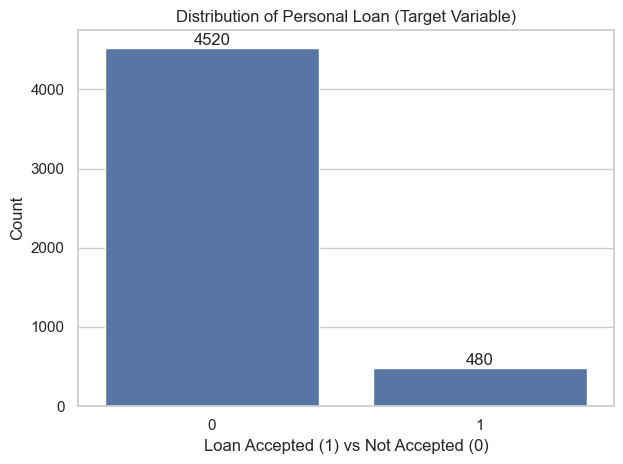

In [19]:
plt.figure()

# Create plot and store axis
ax = sns.countplot(x='Personal Loan', data=df)

plt.title('Distribution of Personal Loan (Target Variable)')
plt.xlabel('Loan Accepted (1) vs Not Accepted (0)')
plt.ylabel('Count')

# Add values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

##### Correlation Matrix Heatmap

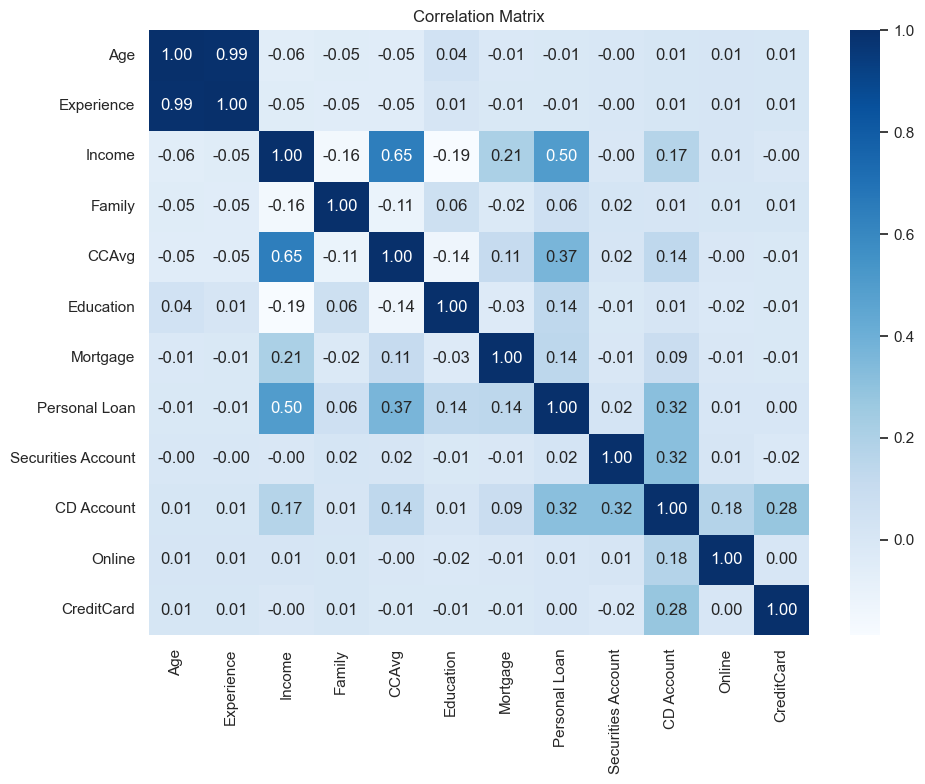

In [20]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

##### Histograms

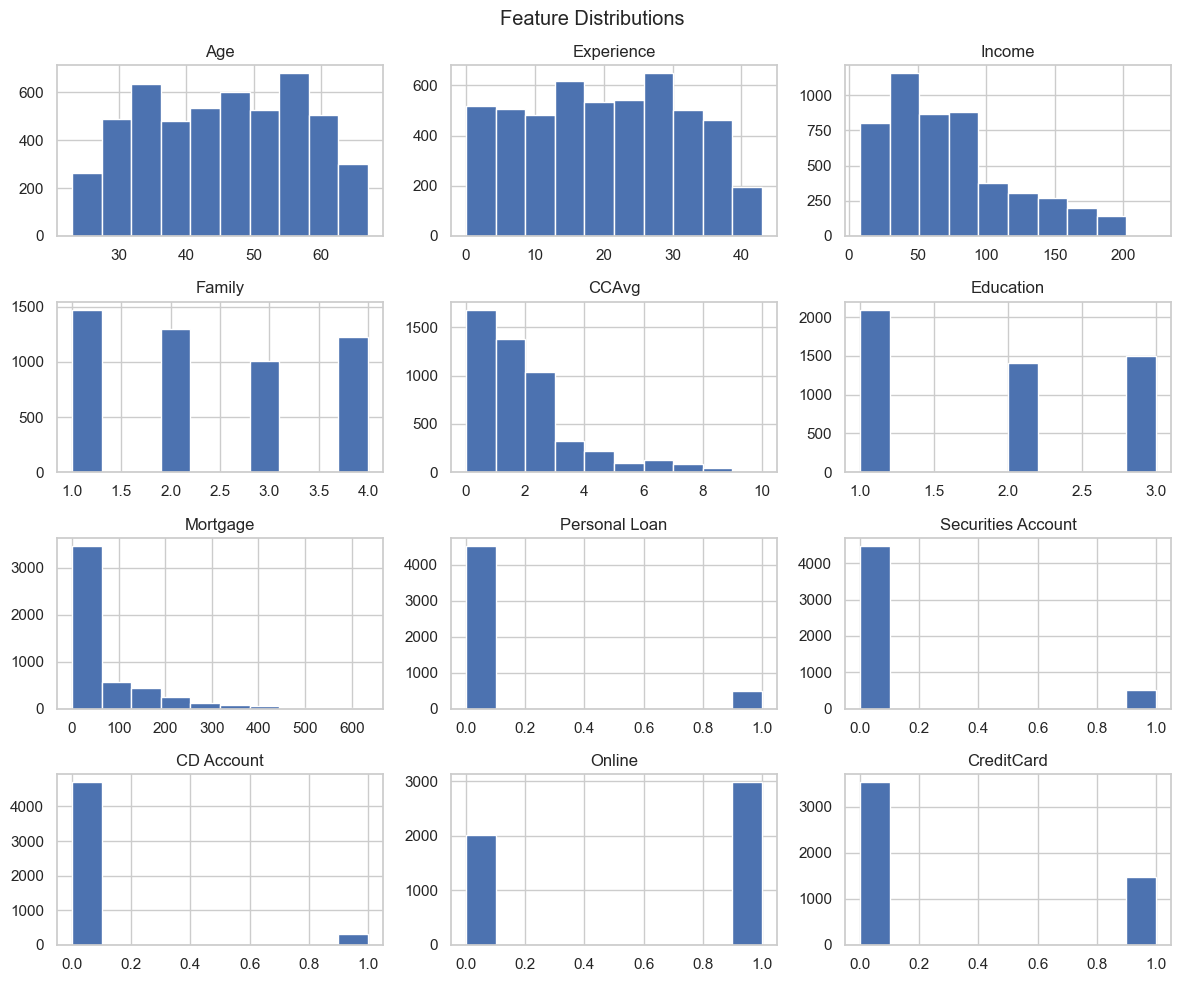

In [21]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

##### Boxplot for Outliers

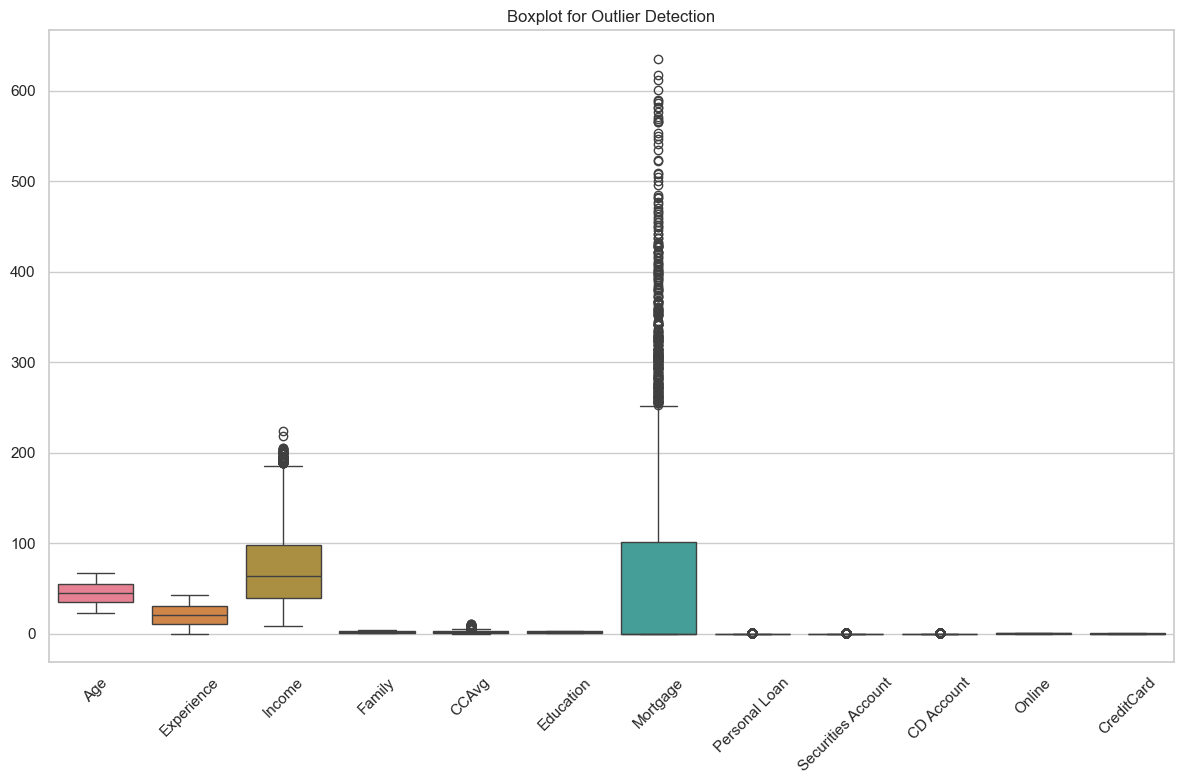

In [22]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

##### Feature / Target Split

In [23]:
# Define X (independent variables) and y (target)
X = df.drop(columns=['Personal Loan'])
y = df['Personal Loan']

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (5000, 11)
Target vector shape: (5000,)


##### Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # maintains class balance
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (3500, 11)
Test shape: (1500, 11)


##### Feature Scaling (Important for Logistic Regression)

In [25]:
scaler = StandardScaler()

# Fit only on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


Feature scaling completed.


### 3 - Logistic Regression Model and Evaluation

##### Model Building - Logistic Regression

In [26]:
# Initialize model
# class_weight='balanced' helps handle class imbalance
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train model
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


##### Predictions

In [27]:
# Predict class labels
y_pred = log_model.predict(X_test_scaled)

# Predict probabilities (needed for interpretation / threshold if required)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

##### Confusion Matrix

In [28]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[1213  143]
 [  14  130]]


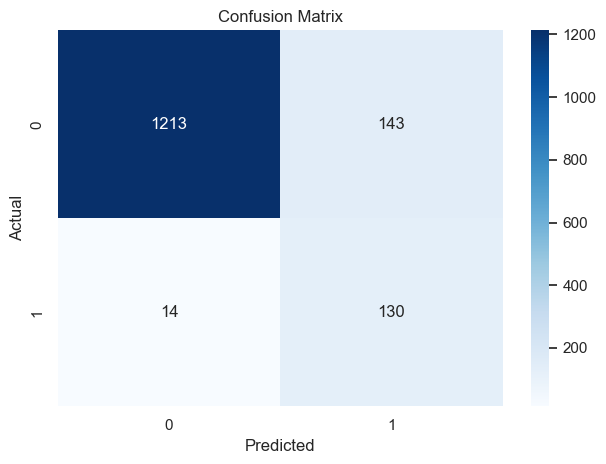

In [29]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

##### Performance Metrics

In [30]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Performance:
Accuracy: 0.8953
Precision: 0.4762
Recall: 0.9028

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1356
           1       0.48      0.90      0.62       144

    accuracy                           0.90      1500
   macro avg       0.73      0.90      0.78      1500
weighted avg       0.94      0.90      0.91      1500



##### Find Most Significant Variables

In [31]:
# Get coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

# Sort by absolute importance
coefficients['Abs_Coeff'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coeff', ascending=False)

print("\nFeature Importance (sorted):")
print(coefficients[['Feature', 'Coefficient']])


Feature Importance (sorted):
               Feature  Coefficient
2               Income     2.300830
5            Education     1.088282
8           CD Account     0.975550
3               Family     0.621620
10          CreditCard    -0.487784
4                CCAvg     0.442021
7   Securities Account    -0.392208
9               Online    -0.308180
0                  Age    -0.191870
1           Experience     0.153785
6             Mortgage     0.063517


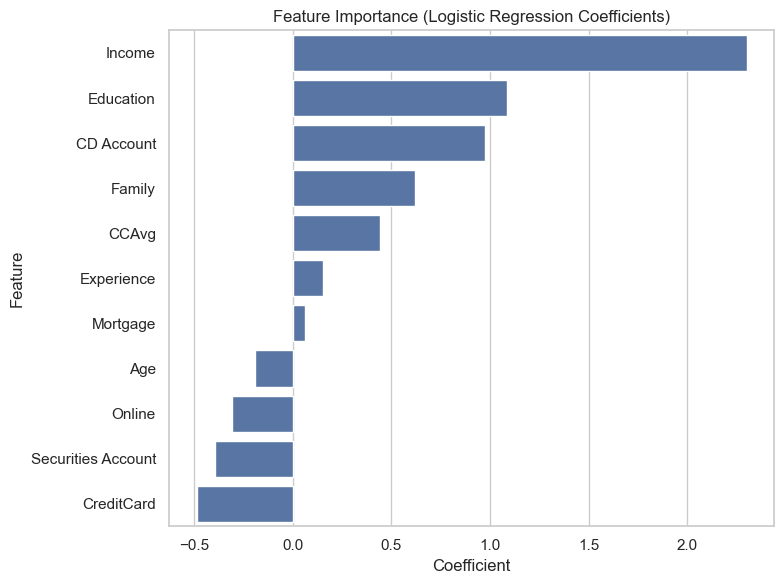

In [32]:
# Feature importance plot
plt.figure(figsize=(8,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients.sort_values(by='Coefficient', ascending=False)
)

plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.tight_layout()
plt.show()

##### Top 3 Important Variables

In [33]:
top3 = coefficients.head(3)
print("\nTop 3 Most Significant Variables:")
print(top3[['Feature', 'Coefficient']])


Top 3 Most Significant Variables:
      Feature  Coefficient
2      Income     2.300830
5   Education     1.088282
8  CD Account     0.975550


##### Most Negative Influence

In [34]:
# Among top 3, find most negative coefficient
most_negative = top3.loc[top3['Coefficient'].idxmin()]

print("\nMost Negative Influential Variable (among top 3):")
print(most_negative[['Feature', 'Coefficient']])


Most Negative Influential Variable (among top 3):
Feature        CD Account
Coefficient       0.97555
Name: 8, dtype: object
